This script creates Figure 4 of the main paper

In [1]:
#import packges

import skill_metrics as sm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from natsort import natsorted 
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec


ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#load lat and lon

outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat

lat2=lat[44:]
lat3=lat[22:50]

In [4]:
#load observations
outputdir='/glade/work/nmaher/SEOF_output/'
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'


model='OBS'
#option for single files - put one file path here to get lon/lat/time
ds_fx = xr.open_dataset(outputdir+'20CRv3.z500.eof.npac.djf.1958-2015.nc_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat
time = ds_fx.time

eof_T='_PNA'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eof = np.ma.MaskedArray(**npz)
    

eof_T='_NAT'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eofNat = np.ma.MaskedArray(**npz)
  

model='OBS_ERSST'

eof_T='_TPAC_SST'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eofTpac = np.ma.MaskedArray(**npz)
    
#eof=eof[:,44:,:]  
#eofNat=eofNat[:,44:,:]  
#eofTpac=eofTpac[:,22:50,:]  


eof2 = np.ma.masked_equal(np.zeros([3,72,144]),0)
eofNat2 = np.ma.masked_equal(np.zeros([1,72,144]),0)
eofTpac2 = np.ma.masked_equal(np.zeros([2,72,144]),0)

for i in range(72):
    eof2[:,i,:]=eof[:,i,:]*np.cos(lat[i]*(np.pi/180))        
    eofNat2[:,i,:]=eofNat[:,i,:]*np.cos(lat[i]*(np.pi/180))   
    eofTpac2[:,i,:]=eofTpac[:,i,:]*np.cos(lat[i]*(np.pi/180))   




eof2[1,:,:]=eof2[1,:,:]*-1
eof2[2,:,:]=eof2[2,:,:]
eofTpac2[1,:,:]=eofTpac2[1,:,:]*-1



In [5]:
#deinfe model data

models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]

outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'

eof_T1='_PNA'
eof_T2='_NAT'
eof_T3='_TPAC_SST'



In [6]:
#load model data and compute the inputs needed for a Taylor diagram - each cell from here does one model

model=models[0]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   

data_z500_tpac2[:,1,:,:]=data_z500_tpac2[:,1,:,:]*-1
data_z500_npac2[:,2,:,:]=data_z500_npac2[:,2,:,:]*-1

e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 


CESM2_sdev=np.array([sdev[0],np.mean(sdev[1:])])
CESM2_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
CESM2_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
CESM2_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
CESM2_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
CESM2_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
CESM2_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
CESM2_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
CESM2_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
CESM2_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
CESM2_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
CESM2_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
CESM2_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
CESM2_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
CESM2_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
CESM2_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
CESM2_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
CESM2_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

CESM2b_sdev=sdev
CESM2b_crmsd=crmsd
CESM2b_ccoef=ccoef
CESM2b_sdev1=sdev1
CESM2b_crmsd1=crmsd1
CESM2b_ccoef1=ccoef1
CESM2b_sdev2=sdev2
CESM2b_crmsd2=crmsd2
CESM2b_ccoef2=ccoef2
CESM2b_sdev3=sdev3
CESM2b_crmsd3=crmsd3
CESM2b_ccoef3=ccoef3
CESM2b_sdev4=sdev4
CESM2b_crmsd4=crmsd4
CESM2b_ccoef4=ccoef4
CESM2b_sdev5=sdev5
CESM2b_crmsd5=crmsd5
CESM2b_ccoef5=ccoef5

In [7]:
   
model=models[1]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)


for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   


   
data_z500_nat2=data_z500_nat2*-1
data_z500_npac2[:,1,:,:]=data_z500_npac2[:,1,:,:]*-1
data_z500_tpac2[:,0,:,:]=data_z500_tpac2[:,0,:,:]*-1
data_z500_npac2[:,2,:,:]=data_z500_npac2[:,2,:,:]*-1


e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 



CESM1_sdev=np.array([sdev[0],np.mean(sdev[1:])])
CESM1_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
CESM1_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
CESM1_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
CESM1_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
CESM1_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
CESM1_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
CESM1_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
CESM1_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
CESM1_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
CESM1_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
CESM1_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
CESM1_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
CESM1_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
CESM1_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
CESM1_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
CESM1_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
CESM1_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])


CESM1b_sdev=sdev
CESM1b_crmsd=crmsd
CESM1b_ccoef=ccoef
CESM1b_sdev1=sdev1
CESM1b_crmsd1=crmsd1
CESM1b_ccoef1=ccoef1
CESM1b_sdev2=sdev2
CESM1b_crmsd2=crmsd2
CESM1b_ccoef2=ccoef2
CESM1b_sdev3=sdev3
CESM1b_crmsd3=crmsd3
CESM1b_ccoef3=ccoef3
CESM1b_sdev4=sdev4
CESM1b_crmsd4=crmsd4
CESM1b_ccoef4=ccoef4
CESM1b_sdev5=sdev5
CESM1b_crmsd5=crmsd5
CESM1b_ccoef5=ccoef5

In [8]:
     
model=models[2]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   


data_z500_npac2[:,0,:,:]=data_z500_npac2[:,0,:,:]*-1
data_z500_tpac2[:,0,:,:]=data_z500_tpac2[:,0,:,:]*-1
data_z500_npac2[:,2,:,:]=data_z500_npac2[:,2,:,:]*-1


e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 


AC_sdev=np.array([sdev[0],np.mean(sdev[1:])])
AC_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
AC_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
AC_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
AC_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
AC_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
AC_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
AC_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
AC_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
AC_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
AC_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
AC_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
AC_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
AC_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
AC_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
AC_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
AC_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
AC_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

ACb_sdev=sdev
ACb_crmsd=crmsd
ACb_ccoef=ccoef
ACb_sdev1=sdev1
ACb_crmsd1=crmsd1
ACb_ccoef1=ccoef1
ACb_sdev2=sdev2
ACb_crmsd2=crmsd2
ACb_ccoef2=ccoef2
ACb_sdev3=sdev3
ACb_crmsd3=crmsd3
ACb_ccoef3=ccoef3
ACb_sdev4=sdev4
ACb_crmsd4=crmsd4
ACb_ccoef4=ccoef4
ACb_sdev5=sdev5
ACb_crmsd5=crmsd5
ACb_ccoef5=ccoef5

In [9]:
     
model=models[3]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   



data_z500_nat2=data_z500_nat*-1
data_z500_npac2[:,0,:,:]=data_z500_npac2[:,0,:,:]*-1

e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 



Can_sdev=np.array([sdev[0],np.mean(sdev[1:])])
Can_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
Can_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
Can_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
Can_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
Can_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
Can_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
Can_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
Can_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
Can_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
Can_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
Can_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
Can_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
Can_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
Can_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
Can_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
Can_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
Can_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

Canb_sdev=sdev
Canb_crmsd=crmsd
Canb_ccoef=ccoef
Canb_sdev1=sdev1
Canb_crmsd1=crmsd1
Canb_ccoef1=ccoef1
Canb_sdev2=sdev2
Canb_crmsd2=crmsd2
Canb_ccoef2=ccoef2
Canb_sdev3=sdev3
Canb_crmsd3=crmsd3
Canb_ccoef3=ccoef3
Canb_sdev4=sdev4
Canb_crmsd4=crmsd4
Canb_ccoef4=ccoef4
Canb_sdev5=sdev5
Canb_crmsd5=crmsd5
Canb_ccoef5=ccoef5

In [10]:
model=models[4]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    
data_z500_nat2=data_z500_nat2*-1
data_z500_npac2[:,1,:,:]=data_z500_npac2[:,1,:,:]*-1
data_z500_tpac2[:,0,:,:]=data_z500_tpac2[:,0,:,:]*-1
data_z500_npac2[:,2,:,:]=data_z500_npac2[:,2,:,:]*-1

e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 


SP_sdev=np.array([sdev[0],np.mean(sdev[1:])])
SP_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
SP_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
SP_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
SP_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
SP_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
SP_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
SP_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
SP_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
SP_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
SP_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
SP_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
SP_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
SP_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
SP_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
SP_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
SP_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
SP_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

SPb_sdev=sdev
SPb_crmsd=crmsd
SPb_ccoef=ccoef
SPb_sdev1=sdev1
SPb_crmsd1=crmsd1
SPb_ccoef1=ccoef1
SPb_sdev2=sdev2
SPb_crmsd2=crmsd2
SPb_ccoef2=ccoef2
SPb_sdev3=sdev3
SPb_crmsd3=crmsd3
SPb_ccoef3=ccoef3
SPb_sdev4=sdev4
SPb_crmsd4=crmsd4
SPb_ccoef4=ccoef4
SPb_sdev5=sdev5
SPb_crmsd5=crmsd5
SPb_ccoef5=ccoef5

In [11]:
model=models[5]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   


data_z500_nat2=data_z500_nat2*-1
data_z500_npac2[:,0,:,:]=data_z500_npac2[:,0,:,:]*-1
data_z500_tpac2[:,0,:,:]=data_z500_tpac2[:,0,:,:]*-1
data_z500_npac2[:,1,:,:]=data_z500_npac2[:,1,:,:]*-1
data_z500_tpac2[:,1,:,:]=data_z500_tpac2[:,1,:,:]*-1


e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 


IP_sdev=np.array([sdev[0],np.mean(sdev[1:])])
IP_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
IP_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
IP_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
IP_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
IP_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
IP_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
IP_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
IP_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
IP_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
IP_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
IP_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
IP_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
IP_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
IP_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
IP_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
IP_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
IP_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

IPb_sdev=sdev
IPb_crmsd=crmsd
IPb_ccoef=ccoef
IPb_sdev1=sdev1
IPb_crmsd1=crmsd1
IPb_ccoef1=ccoef1
IPb_sdev2=sdev2
IPb_crmsd2=crmsd2
IPb_ccoef2=ccoef2
IPb_sdev3=sdev3
IPb_crmsd3=crmsd3
IPb_ccoef3=ccoef3
IPb_sdev4=sdev4
IPb_crmsd4=crmsd4
IPb_ccoef4=ccoef4
IPb_sdev5=sdev5
IPb_crmsd5=crmsd5
IPb_ccoef5=ccoef5

In [12]:
model=models[6]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    
data_z500_npac2[:,1,:,:]=data_z500_npac2[:,1,:,:]*-1
data_z500_tpac2[:,0,:,:]=data_z500_tpac2[:,0,:,:]*-1
data_z500_npac2[:,2,:,:]=data_z500_npac2[:,2,:,:]*-1

e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 




M6_sdev=np.array([sdev[0],np.mean(sdev[1:])])
M6_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
M6_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
M6_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
M6_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
M6_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
M6_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
M6_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
M6_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
M6_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
M6_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
M6_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
M6_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
M6_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
M6_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
M6_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
M6_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
M6_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

M6b_sdev=sdev
M6b_crmsd=crmsd
M6b_ccoef=ccoef
M6b_sdev1=sdev1
M6b_crmsd1=crmsd1
M6b_ccoef1=ccoef1
M6b_sdev2=sdev2
M6b_crmsd2=crmsd2
M6b_ccoef2=ccoef2
M6b_sdev3=sdev3
M6b_crmsd3=crmsd3
M6b_ccoef3=ccoef3
M6b_sdev4=sdev4
M6b_crmsd4=crmsd4
M6b_ccoef4=ccoef4
M6b_sdev5=sdev5
M6b_crmsd5=crmsd5
M6b_ccoef5=ccoef5

In [13]:
model=models[7]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    
    
with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#data_z500_npac=data_z500_npac[:,:,44:,:]
#data_z500_nat=data_z500_nat[:,:,44:,:]
#data_z500_tpac=data_z500_tpac[:,:,22:50,:]


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]
tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


data_z500_npac2 = np.ma.masked_equal(np.zeros([ntt,3,72,144]),0)
data_z500_nat2 = np.ma.masked_equal(np.zeros([ntt,1,72,144]),0)
data_z500_tpac2 = np.ma.masked_equal(np.zeros([ntt,2,72,144]),0)

for i in range(72):
    data_z500_npac2[:,:,i,:]=pna_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))        
    data_z500_nat2[:,:,i,:]=nat_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   
    data_z500_tpac2[:,:,i,:]=tpac_seof_phcorr[:,:,i,:]*np.cos(lat[i]*(np.pi/180))   


data_z500_npac2[:,0,:,:]=data_z500_npac2[:,0,:,:]*-1
data_z500_tpac2[:,1,:,:]=data_z500_tpac2[:,1,:,:]*-1


e=0
crmsd = np.zeros(ntt+1)
crmsd[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev = np.zeros(ntt+1)
sdev[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev[ii+1] =np.std(data_z500_npac2[ii,e,:,:])


ccoef= np.zeros(ntt+1)
ccoef[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef[ii+1] = ccoefA[0,1] 

    
e=1
crmsd1 = np.zeros(ntt+1)
crmsd1[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd1[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev1 = np.zeros(ntt+1)
sdev1[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev1[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef1= np.zeros(ntt+1)
ccoef1[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef1[ii+1] = ccoefA[0,1] 
    
e=2
crmsd2 = np.zeros(ntt+1)
crmsd2[0]=sm.centered_rms_dev(eof2[e,:,:],eof2[e,:,:])

for ii in range(ntt):
    crmsd2[ii+1] =sm.centered_rms_dev(data_z500_npac2[ii,e,:,:],eof2[e,:,:])
    
sdev2 = np.zeros(ntt+1)
sdev2[0]=np.std(eof2[e,:,:])

for ii in range(ntt):
    sdev2[ii+1] =np.std(data_z500_npac2[ii,e,:,:])

ccoef2= np.zeros(ntt+1)
ccoef2[0]=  1
for ii in range(ntt):
    x=data_z500_npac2[ii,e,:,:]
    y=eof2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef2[ii+1] = ccoefA[0,1] 
    
    
e=0
crmsd3 = np.zeros(ntt+1)
crmsd3[0]=sm.centered_rms_dev(eofNat2[e,:,:],eofNat2[e,:,:])

for ii in range(ntt):
    crmsd3[ii+1] =sm.centered_rms_dev(data_z500_nat2[ii,e,:,:],eofNat2[e,:,:])
    
sdev3 = np.zeros(ntt+1)
sdev3[0]=np.std(eofNat2[e,:,:])

for ii in range(ntt):
    sdev3[ii+1] =np.std(data_z500_nat2[ii,e,:,:])


ccoef3= np.zeros(ntt+1)
ccoef3[0]=  1
for ii in range(ntt):
    x=data_z500_nat2[ii,e,:,:]
    y=eofNat2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef3[ii+1] = ccoefA[0,1] 
    
e=0
crmsd4 = np.zeros(ntt+1)
crmsd4[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd4[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev4 = np.zeros(ntt+1)
sdev4[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev4[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef4= np.zeros(ntt+1)
ccoef4[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,61:105]
    y=eofTpac2[e,:,61:105]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef4[ii+1] = ccoefA[0,1] 
    
e=1
crmsd5 = np.zeros(ntt+1)
crmsd5[0]=sm.centered_rms_dev(eofTpac2[e,:,:],eofTpac2[e,:,:])

for ii in range(ntt):
    crmsd5[ii+1] =sm.centered_rms_dev(data_z500_tpac2[ii,e,:,:],eofTpac2[e,:,:])
    
sdev5 = np.zeros(ntt+1)
sdev5[0]=np.std(eofTpac2[e,:,:])

for ii in range(ntt):
    sdev5[ii+1] =np.std(data_z500_tpac2[ii,e,:,:])


ccoef5= np.zeros(ntt+1)
ccoef5[0]=  1
for ii in range(ntt):
    x=data_z500_tpac2[ii,e,:,:]
    y=eofTpac2[e,:,:]
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = ccoefA[0,1] 


    
MP_sdev=np.array([sdev[0],np.mean(sdev[1:])])
MP_crmsd=np.array([crmsd[0],np.mean(crmsd[1:])])
MP_ccoef=np.array([ccoef[0],np.mean(ccoef[1:])])
MP_sdev1=np.array([sdev1[0],np.mean(sdev1[1:])])
MP_crmsd1=np.array([crmsd1[0],np.mean(crmsd1[1:])])
MP_ccoef1=np.array([ccoef1[0],np.mean(ccoef1[1:])])
MP_sdev2=np.array([sdev2[0],np.mean(sdev2[1:])])
MP_crmsd2=np.array([crmsd2[0],np.mean(crmsd2[1:])])
MP_ccoef2=np.array([ccoef2[0],np.mean(ccoef2[1:])])
MP_sdev3=np.array([sdev3[0],np.mean(sdev3[1:])])
MP_crmsd3=np.array([crmsd3[0],np.mean(crmsd3[1:])])
MP_ccoef3=np.array([ccoef3[0],np.mean(ccoef3[1:])])
MP_sdev4=np.array([sdev4[0],np.mean(sdev4[1:])])
MP_crmsd4=np.array([crmsd4[0],np.mean(crmsd4[1:])])
MP_ccoef4=np.array([ccoef4[0],np.mean(ccoef4[1:])])
MP_sdev5=np.array([sdev5[0],np.mean(sdev5[1:])])
MP_crmsd5=np.array([crmsd5[0],np.mean(crmsd5[1:])])
MP_ccoef5=np.array([ccoef5[0],np.mean(ccoef5[1:])])

MPb_sdev=sdev
MPb_crmsd=crmsd
MPb_ccoef=ccoef
MPb_sdev1=sdev1
MPb_crmsd1=crmsd1
MPb_ccoef1=ccoef1
MPb_sdev2=sdev2
MPb_crmsd2=crmsd2
MPb_ccoef2=ccoef2
MPb_sdev3=sdev3
MPb_crmsd3=crmsd3
MPb_ccoef3=ccoef3
MPb_sdev4=sdev4
MPb_crmsd4=crmsd4
MPb_ccoef4=ccoef4
MPb_sdev5=sdev5
MPb_crmsd5=crmsd5
MPb_ccoef5=ccoef5

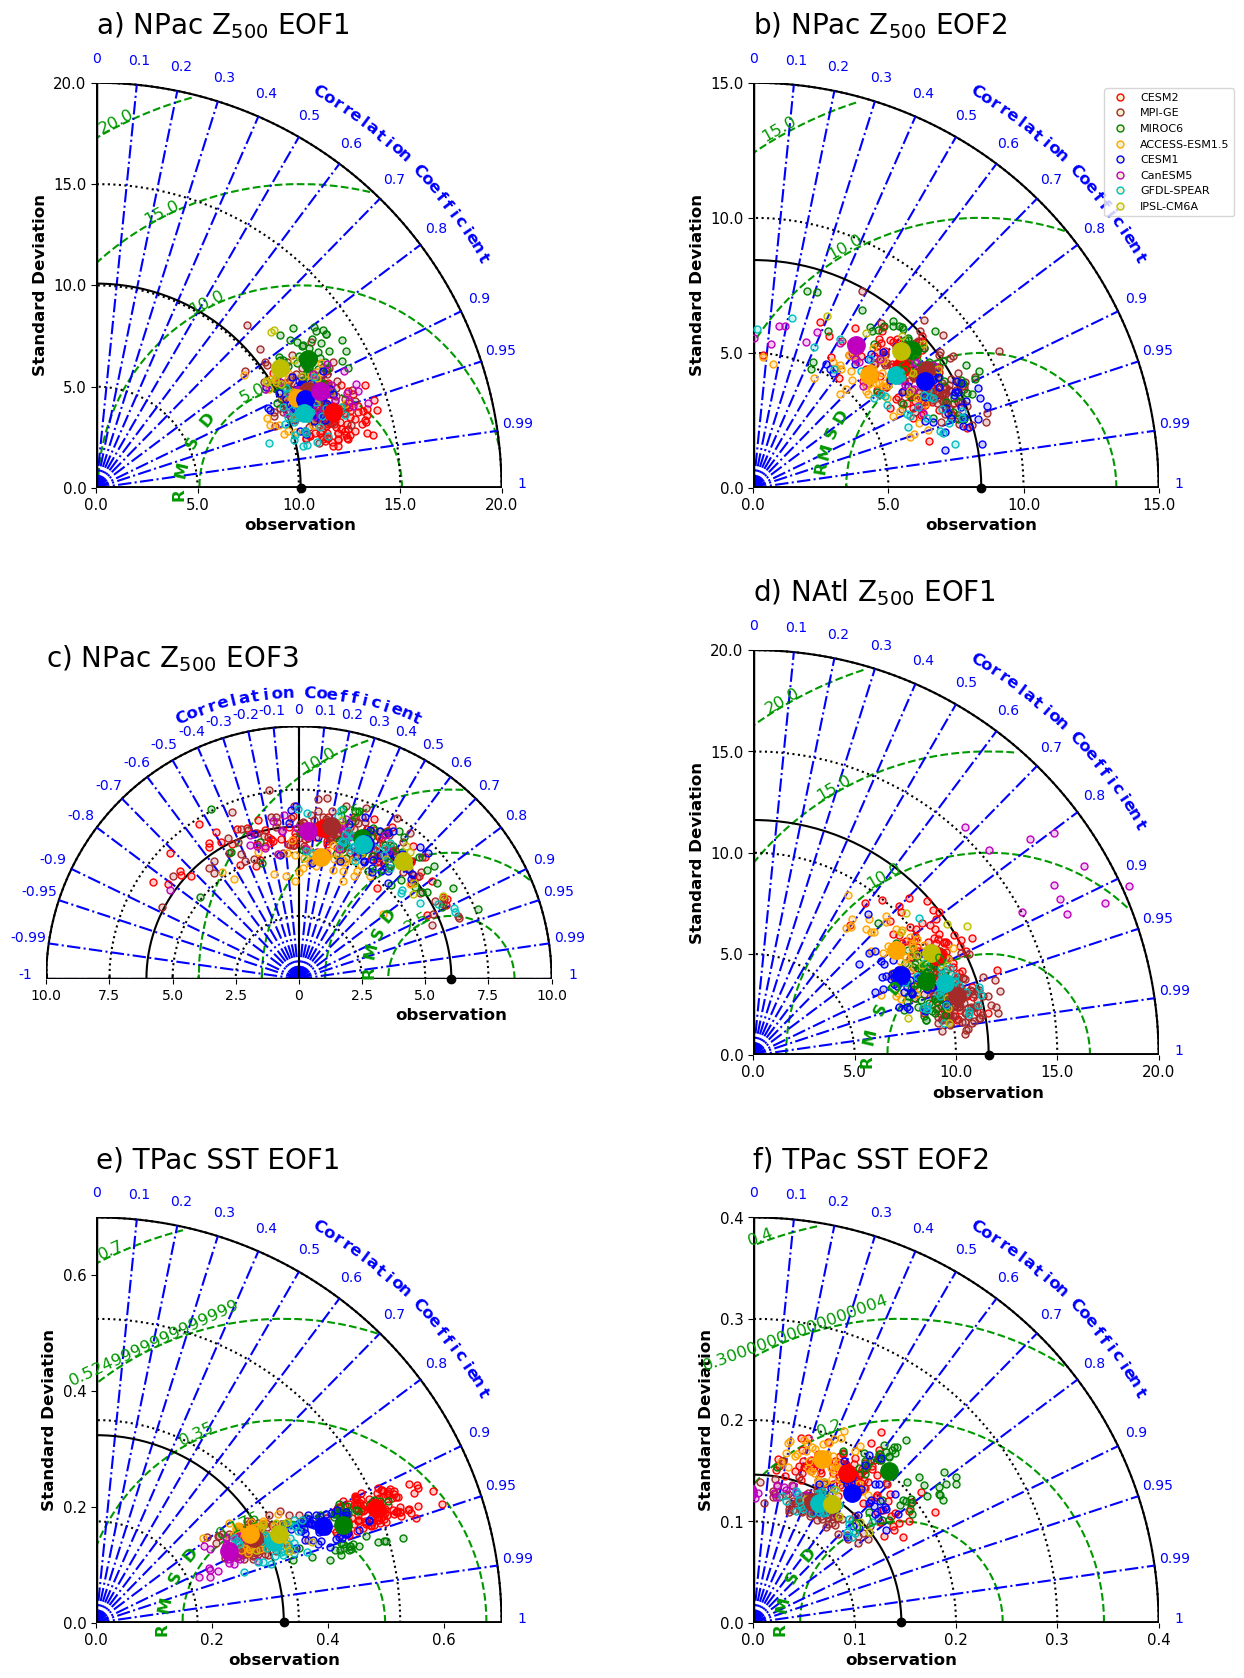

In [31]:
#create the plot


label = ['obs']+models

#plot data
fig = plt.figure(figsize=(15, 20), edgecolor='w')
gs=GridSpec(3,2, wspace=0.3,hspace=0.4)

ax =plt.subplot(gs[0,0])

sm.taylor_diagram(CESM2b_sdev,CESM2b_crmsd,CESM2b_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 20.0, alpha = 0.2)

sm.taylor_diagram(MPb_sdev,MPb_crmsd,MPb_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev,M6b_crmsd,M6b_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev,ACb_crmsd,ACb_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev,CESM1b_crmsd,CESM1b_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev,Canb_crmsd,Canb_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev,SPb_crmsd,SPb_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)

sm.taylor_diagram(IPb_sdev,IPb_crmsd,IPb_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2)

##emean

sm.taylor_diagram(CESM2_sdev,CESM2_crmsd,CESM2_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 20.0,overlay='on', markersize=25)

sm.taylor_diagram(MP_sdev,MP_crmsd,MP_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on',markersize=25)

sm.taylor_diagram(M6_sdev,M6_crmsd,M6_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on',markersize=25)


sm.taylor_diagram(AC_sdev,AC_crmsd,AC_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on',markersize=25)

sm.taylor_diagram(CESM1_sdev,CESM1_crmsd,CESM1_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on',markersize=25)


sm.taylor_diagram(Can_sdev,Can_crmsd,Can_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', markersize=25)

sm.taylor_diagram(SP_sdev,SP_crmsd,SP_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on',markersize=25)

sm.taylor_diagram(IP_sdev,IP_crmsd,IP_ccoef, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on',markersize=25)


ax.set_title('a) NPac Z$_{500}$ EOF1', loc="left", y=1.1,fontsize=20)



ax =plt.subplot(gs[1,0])

sm.taylor_diagram(CESM2b_sdev2,CESM2b_crmsd2,CESM2b_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 10.0, alpha = 0.2)

sm.taylor_diagram(MPb_sdev2,MPb_crmsd2,MPb_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev2,M6b_crmsd2,M6b_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev2,ACb_crmsd2,ACb_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev2,CESM1b_crmsd2,CESM1b_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev2,Canb_crmsd2,Canb_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev2,SPb_crmsd2,SPb_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)

sm.taylor_diagram(IPb_sdev2,IPb_crmsd2,IPb_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2)
##emean

sm.taylor_diagram(CESM2_sdev2,CESM2_crmsd2,CESM2_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 10.0,overlay='on', markersize=25)

sm.taylor_diagram(MP_sdev2,MP_crmsd2,MP_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', markersize=25)

sm.taylor_diagram(M6_sdev2,M6_crmsd2,M6_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', markersize=25)


sm.taylor_diagram(AC_sdev2,AC_crmsd2,AC_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on',markersize=25)

sm.taylor_diagram(CESM1_sdev2,CESM1_crmsd2,CESM1_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on',markersize=25)


sm.taylor_diagram(Can_sdev2,Can_crmsd2,Can_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o',
                      titleOBS = 'observation',markercolor ='m',overlay='on', markersize=25)

sm.taylor_diagram(SP_sdev2,SP_crmsd2,SP_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', markersize=25)

sm.taylor_diagram(IP_sdev2,IP_crmsd2,IP_ccoef2, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', markersize=25)


ax.set_title('c) NPac Z$_{500}$ EOF3', loc="left", y=1.2,fontsize=20)


ax =plt.subplot(gs[1,1])

sm.taylor_diagram(CESM2b_sdev3,CESM2b_crmsd3,CESM2b_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 20.0, alpha = 0.2)

sm.taylor_diagram(MPb_sdev3,MPb_crmsd3,MPb_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev3,M6b_crmsd3,M6b_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev3,ACb_crmsd3,ACb_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev3,CESM1b_crmsd3,CESM1b_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev3,Canb_crmsd3,Canb_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev3,SPb_crmsd3,SPb_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)

sm.taylor_diagram(IPb_sdev3,IPb_crmsd3,IPb_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2)

#emean

sm.taylor_diagram(CESM2_sdev3,CESM2_crmsd3,CESM2_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 20.0,overlay='on', markersize=25)

sm.taylor_diagram(MP_sdev3,MP_crmsd3,MP_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', markersize=25)

sm.taylor_diagram(M6_sdev3,M6_crmsd3,M6_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on',markersize=25)


sm.taylor_diagram(AC_sdev3,AC_crmsd3,AC_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on',markersize=25)

sm.taylor_diagram(CESM1_sdev3,CESM1_crmsd3,CESM1_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o',
                      titleOBS = 'observation',markercolor ='b',overlay='on', markersize=25)


sm.taylor_diagram(Can_sdev3,Can_crmsd3,Can_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o',
                      titleOBS = 'observation',markercolor ='m',overlay='on', markersize=25)

sm.taylor_diagram(SP_sdev3,SP_crmsd3,SP_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on',markersize=25)

sm.taylor_diagram(IP_sdev3,IP_crmsd3,IP_ccoef3, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', markersize=25)


ax.set_title('d) NAtl Z$_{500}$ EOF1', loc="left", y=1.1,fontsize=20)



ax =plt.subplot(gs[0,1])

sm.taylor_diagram(CESM2b_sdev1,CESM2b_crmsd1,CESM2b_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 15.0, alpha = 0.2)

sm.taylor_diagram(MPb_sdev1,MPb_crmsd1,MPb_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev1,M6b_crmsd1,M6b_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev1,ACb_crmsd1,ACb_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev1,CESM1b_crmsd1,CESM1b_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev1,Canb_crmsd1,Canb_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev1,SPb_crmsd1,SPb_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)


label = {'CESM2': 'r', 'MPI-GE': 'brown', 'MIROC6': 'g', 'ACCESS-ESM1.5':'orange','CESM1':'b','CanESM5':'m','GFDL-SPEAR':'c','IPSL-CM6A':'y'}


sm.taylor_diagram(IPb_sdev1,IPb_crmsd1,IPb_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2,markerLabel = label)

#emean

sm.taylor_diagram(CESM2_sdev1,CESM2_crmsd1,CESM2_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 15.0,overlay='on',markersize=25)

sm.taylor_diagram(MP_sdev1,MP_crmsd1,MP_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on',markersize=25)

sm.taylor_diagram(M6_sdev1,M6_crmsd1,M6_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on',markersize=25)


sm.taylor_diagram(AC_sdev1,AC_crmsd1,AC_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', markersize=25)

sm.taylor_diagram(CESM1_sdev1,CESM1_crmsd1,CESM1_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', markersize=25)


sm.taylor_diagram(Can_sdev1,Can_crmsd1,Can_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on',markersize=25)

sm.taylor_diagram(SP_sdev1,SP_crmsd1,SP_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on',markersize=25)


label = {'obs':'k','CESM2': 'r', 'MPI-GE': 'brown', 'MIROC6': 'g', 'ACCESS-ESM1.5':'orange','CESM1':'b','CanESM5':'m','GFDL-SPEAR':'c','IPSL-CM6A':'y'}


sm.taylor_diagram(IP_sdev1,IP_crmsd1,IP_ccoef1, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on',markersize=25)



ax.set_title('b) NPac Z$_{500}$ EOF2', loc="left", y=1.1,fontsize=20)

ax =plt.subplot(gs[2,0])

sm.taylor_diagram(CESM2b_sdev4,CESM2b_crmsd4,CESM2b_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 0.7, alpha = 0.2)

sm.taylor_diagram(MPb_sdev4,MPb_crmsd4,MPb_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev4,M6b_crmsd4,M6b_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev4,ACb_crmsd4,ACb_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev4,CESM1b_crmsd4,CESM1b_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev4,Canb_crmsd4,Canb_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev4,SPb_crmsd4,SPb_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)



sm.taylor_diagram(IPb_sdev4,IPb_crmsd4,IPb_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2)

#emean

sm.taylor_diagram(CESM2_sdev4,CESM2_crmsd4,CESM2_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',overlay='on',markersize=25)

sm.taylor_diagram(MP_sdev4,MP_crmsd4,MP_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on',markersize=25)

sm.taylor_diagram(M6_sdev4,M6_crmsd4,M6_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', markersize=25)


sm.taylor_diagram(AC_sdev4,AC_crmsd4,AC_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on',markersize=25)

sm.taylor_diagram(CESM1_sdev4,CESM1_crmsd4,CESM1_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on',markersize=25)


sm.taylor_diagram(Can_sdev4,Can_crmsd4,Can_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', markersize=25)

sm.taylor_diagram(SP_sdev4,SP_crmsd4,SP_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', markersize=25)



sm.taylor_diagram(IP_sdev4,IP_crmsd4,IP_ccoef4, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', markersize=25)


ax.set_title('e) TPac SST EOF1', loc="left", y=1.1,fontsize=20)



ax =plt.subplot(gs[2,1])

sm.taylor_diagram(CESM2b_sdev5,CESM2b_crmsd5,CESM2b_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 0.4, alpha = 0.2)

sm.taylor_diagram(MPb_sdev5,MPb_crmsd5,MPb_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', alpha = 0.2)

sm.taylor_diagram(M6b_sdev5,M6b_crmsd5,M6b_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', alpha = 0.2)


sm.taylor_diagram(ACb_sdev5,ACb_crmsd5,ACb_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', alpha = 0.2)

sm.taylor_diagram(CESM1b_sdev5,CESM1b_crmsd5,CESM1b_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', alpha = 0.2)


sm.taylor_diagram(Canb_sdev5,Canb_crmsd5,Canb_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on', alpha = 0.2)

sm.taylor_diagram(SPb_sdev5,SPb_crmsd5,SPb_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on', alpha = 0.2)



sm.taylor_diagram(IPb_sdev5,IPb_crmsd5,IPb_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on', alpha = 0.2)

#emean

sm.taylor_diagram(CESM2_sdev5,CESM2_crmsd5,CESM2_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='r',axismax = 0.4 ,overlay='on',markersize=25)

sm.taylor_diagram(MP_sdev5,MP_crmsd5,MP_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='brown',overlay='on', markersize=25)

sm.taylor_diagram(M6_sdev5,M6_crmsd5,M6_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='g',overlay='on', markersize=25)


sm.taylor_diagram(AC_sdev5,AC_crmsd5,AC_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='orange',overlay='on', markersize=25)

sm.taylor_diagram(CESM1_sdev5,CESM1_crmsd5,CESM1_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='b',overlay='on', markersize=25)


sm.taylor_diagram(Can_sdev5,Can_crmsd5,Can_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='m',overlay='on',markersize=25)

sm.taylor_diagram(SP_sdev5,SP_crmsd5,SP_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='c',overlay='on',markersize=25)



sm.taylor_diagram(IP_sdev5,IP_crmsd5,IP_ccoef5, styleOBS = '-', 
                      colOBS = 'k', markerobs = 'o', 
                      titleOBS = 'observation',markercolor ='y',overlay='on',markersize=25)


#sm.taylor_diagram(sdev2[1:10],crmsd2[1:10],ccoef2[1:10], markercolor ='b')

ax.set_title('f) TPac SST EOF2', loc="left", y=1.1,fontsize=20)
plt.rcParams["legend.fontsize"] = 18

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
plt.savefig(outputdir2+'Figure4.png', dpi=300, bbox_inches='tight')
